# Per-Patient Analysis: Who Benefits Most from CNN Correction?

Investigates the per-patient error reduction from CNN phase error correction.
Examines whether certain patient characteristics (flow magnitude, Qp/Qs, pathology)
predict how much the CNN correction improves agreement with manual correction.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from scipy import stats

NOTEBOOK_DIR = Path.home() / "vascular-superenhancement-4d-flow" / "notebooks" / "analysis" / "PEC_quantitative_analysis"
DATA_CSV = NOTEBOOK_DIR / "consolidated.csv"
ERROR_CSV = NOTEBOOK_DIR / "error_metrics.csv"

COLORS = {"uncorrected": "#5B8EC9", "cnn": "#E8855E", "manual": "#6EAE6E"}
LABELS = {"uncorrected": "Uncorrected", "cnn": "CNN Corrected", "manual": "Manual"}
VESSELS = ["Ao", "PA"]
VESSEL_LABELS = {"Ao": "Aorta", "PA": "Pulmonary Artery"}

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.3,
    "grid.linewidth": 0.5,
})

data = pd.read_csv(DATA_CSV)
compared = pd.read_csv(ERROR_CSV)
print(f"{data['patient'].nunique()} patients")

15 patients


## 1. Per-patient error reduction

For each patient and vessel, compute:
- Error reduction = |uncorrected error| − |CNN error|
- Positive = CNN is closer to manual

In [2]:
flow_pivot = data.pivot_table(
    index=["patient", "vessel"],
    columns="method",
    values="flow",
).reset_index()

flow_pivot["cnn_error"] = flow_pivot["cnn"] - flow_pivot["manual"]
flow_pivot["uncorrected_error"] = flow_pivot["uncorrected"] - flow_pivot["manual"]
flow_pivot["cnn_abs_error"] = flow_pivot["cnn_error"].abs()
flow_pivot["uncorrected_abs_error"] = flow_pivot["uncorrected_error"].abs()
flow_pivot["error_reduction"] = flow_pivot["uncorrected_abs_error"] - flow_pivot["cnn_abs_error"]
flow_pivot["pct_error_reduction"] = (
    flow_pivot["error_reduction"] / flow_pivot["uncorrected_abs_error"] * 100
).replace([np.inf, -np.inf], np.nan)

response = flow_pivot.pivot_table(
    index="patient",
    columns="vessel",
    values="error_reduction",
)
response.columns = [f"reduction_{v}" for v in response.columns]

for vessel in VESSELS:
    col = f"reduction_{vessel}"
    if col in response.columns:
        print(f"--- {VESSEL_LABELS[vessel]} ---")
        display(response[[col]].dropna().sort_values(col, ascending=False).round(3))
        print()

--- Aorta ---


,reduction_Ao
patient,
Diecudey,1.66
Diequipi,1.65
Tiepolem,1.30
Biswifo,1.23
Oduskueb,1.07
Suquepog,1.04
Diepami,0.89
Gueshifa,0.67
Dujomal,0.66



--- Pulmonary Artery ---


,reduction_PA
patient,
Tiepolem,2.07
Diequipi,1.63
Gueshifa,1.24
Diepami,1.21
Dublafer,1.09
Balboloop,1.02
Biswifo,0.65
Detodu,0.63
Suquepog,0.57


## 2. Waterfall plot: error reduction by patient

Positive bars = CNN correction reduced error; negative = CNN made it worse.

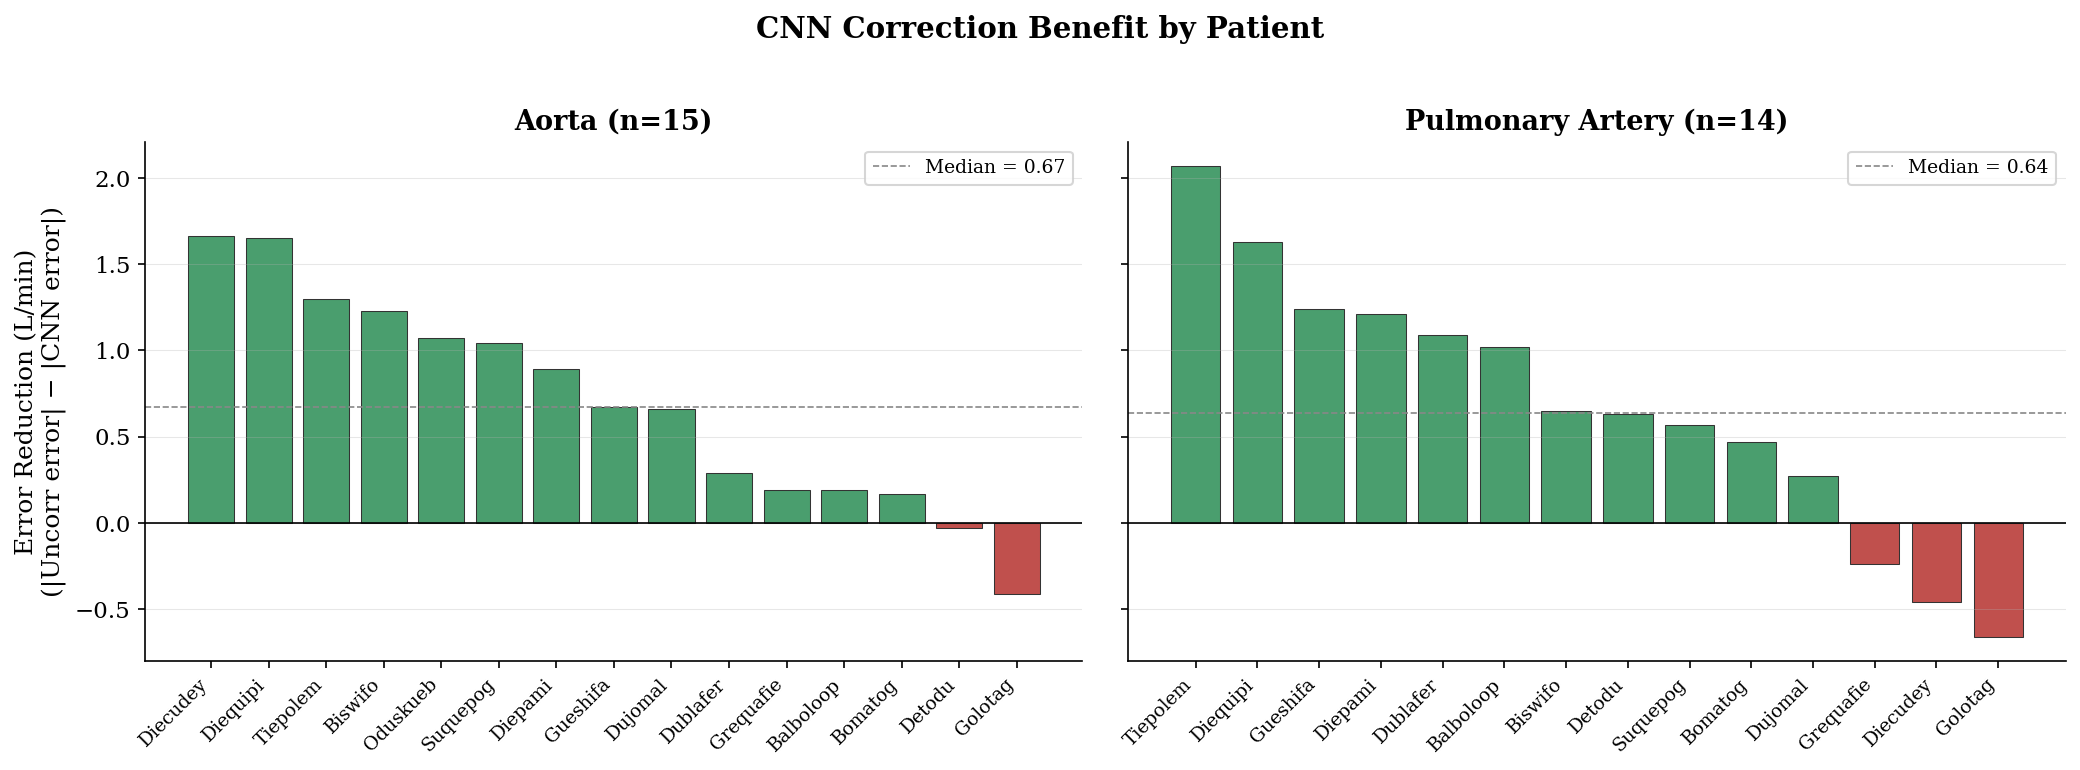

In [3]:
fig, axes = plt.subplots(1, len(VESSELS), figsize=(7 * len(VESSELS), 5), sharey=True)

for ax, vessel in zip(axes, VESSELS):
    col = f"reduction_{vessel}"
    valid = response[[col]].dropna().sort_values(col, ascending=False)
    colors = ["#4a9e6e" if v >= 0 else "#c0504d" for v in valid[col]]

    ax.bar(range(len(valid)), valid[col], color=colors, edgecolor="#333", linewidth=0.5)
    ax.set_xticks(range(len(valid)))
    ax.set_xticklabels(valid.index, rotation=45, ha="right", fontsize=9)
    n_v = len(flow_pivot[flow_pivot["vessel"] == vessel].dropna()); ax.set_title(f"{VESSEL_LABELS[vessel]} (n={n_v})", fontweight="bold")
    ax.axhline(0, color="black", linewidth=0.8)

    med = valid[col].median()
    ax.axhline(med, color="#888", linestyle="--", linewidth=0.8,
               label=f"Median = {med:.2f}")
    ax.legend(fontsize=9)

axes[0].set_ylabel("Error Reduction (L/min)\n(|Uncorr error| − |CNN error|)")
fig.suptitle("CNN Correction Benefit by Patient",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

## 3. Percentage error reduction

What fraction of the original uncorrected error was removed by CNN correction?

In [4]:
for vessel in VESSELS:
    vp = flow_pivot[flow_pivot["vessel"] == vessel].dropna(subset=["pct_error_reduction"])
    print(f"--- {VESSEL_LABELS[vessel]} ---")
    pct = vp[["patient", "pct_error_reduction", "uncorrected_abs_error", "cnn_abs_error"]].copy()
    pct = pct.sort_values("pct_error_reduction", ascending=False)
    display(pct.round(1))

    improved = (pct["pct_error_reduction"] > 0).sum()
    total = len(pct)
    print(f"  CNN improved: {improved}/{total} ({improved/total*100:.0f}%)")
    print(f"  Median % error reduction: {pct['pct_error_reduction'].median():.1f}%")
    print()

--- Aorta ---


method,patient,pct_error_reduction,uncorrected_abs_error,cnn_abs_error
2,Biswifo,99.2,1.2,0.0
8,Diecudey,98.8,1.7,0.0
12,Diequipi,93.2,1.8,0.1
24,Oduskueb,90.7,1.2,0.1
27,Tiepolem,85.0,1.5,0.2
16,Dujomal,75.9,0.9,0.2
22,Gueshifa,72.8,0.9,0.2
25,Suquepog,72.7,1.4,0.4
14,Dublafer,64.4,0.4,0.2
20,Grequafie,61.3,0.3,0.1


  CNN improved: 13/15 (87%)
  Median % error reduction: 72.7%

--- Pulmonary Artery ---


method,patient,pct_error_reduction,uncorrected_abs_error,cnn_abs_error
15,Dublafer,100.0,1.1,0.0
13,Diequipi,94.8,1.7,0.1
1,Balboloop,91.9,1.1,0.1
26,Suquepog,86.4,0.7,0.1
28,Tiepolem,86.2,2.4,0.3
3,Biswifo,75.6,0.9,0.2
7,Detodu,75.0,0.8,0.2
23,Gueshifa,74.7,1.7,0.4
5,Bomatog,49.5,1.0,0.5
11,Diepami,46.9,2.6,1.4


  CNN improved: 11/14 (79%)
  Median % error reduction: 74.8%



## 4. What predicts correction benefit?

Check whether the magnitude of the uncorrected error, manual flow magnitude,
or other features correlate with how much the CNN correction helps.

In [5]:
patient_features = []
patients = sorted(data["patient"].unique())

for pt in patients:
    row = {"patient": pt}
    for vessel in VESSELS:
        sub = data[(data["patient"] == pt) & (data["vessel"] == vessel)]
        manual_flow = sub[sub["method"] == "manual"]["flow"].values
        if len(manual_flow):
            row[f"manual_flow_{vessel}"] = manual_flow[0]
        uncorr_flow = sub[sub["method"] == "uncorrected"]["flow"].values
        if len(uncorr_flow):
            row[f"uncorr_flow_{vessel}"] = uncorr_flow[0]
    patient_features.append(row)

feat_df = pd.DataFrame(patient_features).set_index("patient")
combined = feat_df.join(response)

# Also add uncorrected absolute error as a predictor
for vessel in VESSELS:
    vp = flow_pivot[flow_pivot["vessel"] == vessel][["patient", "uncorrected_abs_error"]]
    vp = vp.set_index("patient").rename(columns={"uncorrected_abs_error": f"uncorr_abs_error_{vessel}"})
    combined = combined.join(vp)

predictors = [c for c in combined.columns if c.startswith(("manual_flow", "uncorr_flow", "uncorr_abs_error"))]

for vessel in VESSELS:
    col = f"reduction_{vessel}"
    if col not in combined.columns:
        continue
    print(f"--- {VESSEL_LABELS[vessel]} ---")
    print(f"{'Predictor':<28s}  {'r':>8s}  {'p':>8s}")
    print("-" * 48)
    for pred in predictors:
        valid = combined[[pred, col]].dropna()
        if len(valid) < 4:
            continue
        r, p = stats.pearsonr(valid[pred], valid[col])
        sig = " *" if p < 0.05 else ""
        print(f"{pred:<28s}  {r:+7.3f}{sig}  {p:8.4f}")
    print()

--- Aorta ---
Predictor                            r         p
------------------------------------------------
manual_flow_Ao                 -0.091    0.7482
uncorr_flow_Ao                 +0.202    0.4700
manual_flow_PA                 -0.506    0.0651
uncorr_flow_PA                 -0.375    0.1869
uncorr_abs_error_Ao            +0.864 *    0.0000
uncorr_abs_error_PA            +0.387    0.1714

--- Pulmonary Artery ---
Predictor                            r         p
------------------------------------------------
manual_flow_Ao                 -0.404    0.1515
uncorr_flow_Ao                 -0.216    0.4577
manual_flow_PA                 -0.827 *    0.0003
uncorr_flow_PA                 -0.382    0.1779
uncorr_abs_error_Ao            +0.450    0.1060
uncorr_abs_error_PA            +0.699 *    0.0054



## 5. Scatter: uncorrected error magnitude vs CNN correction benefit

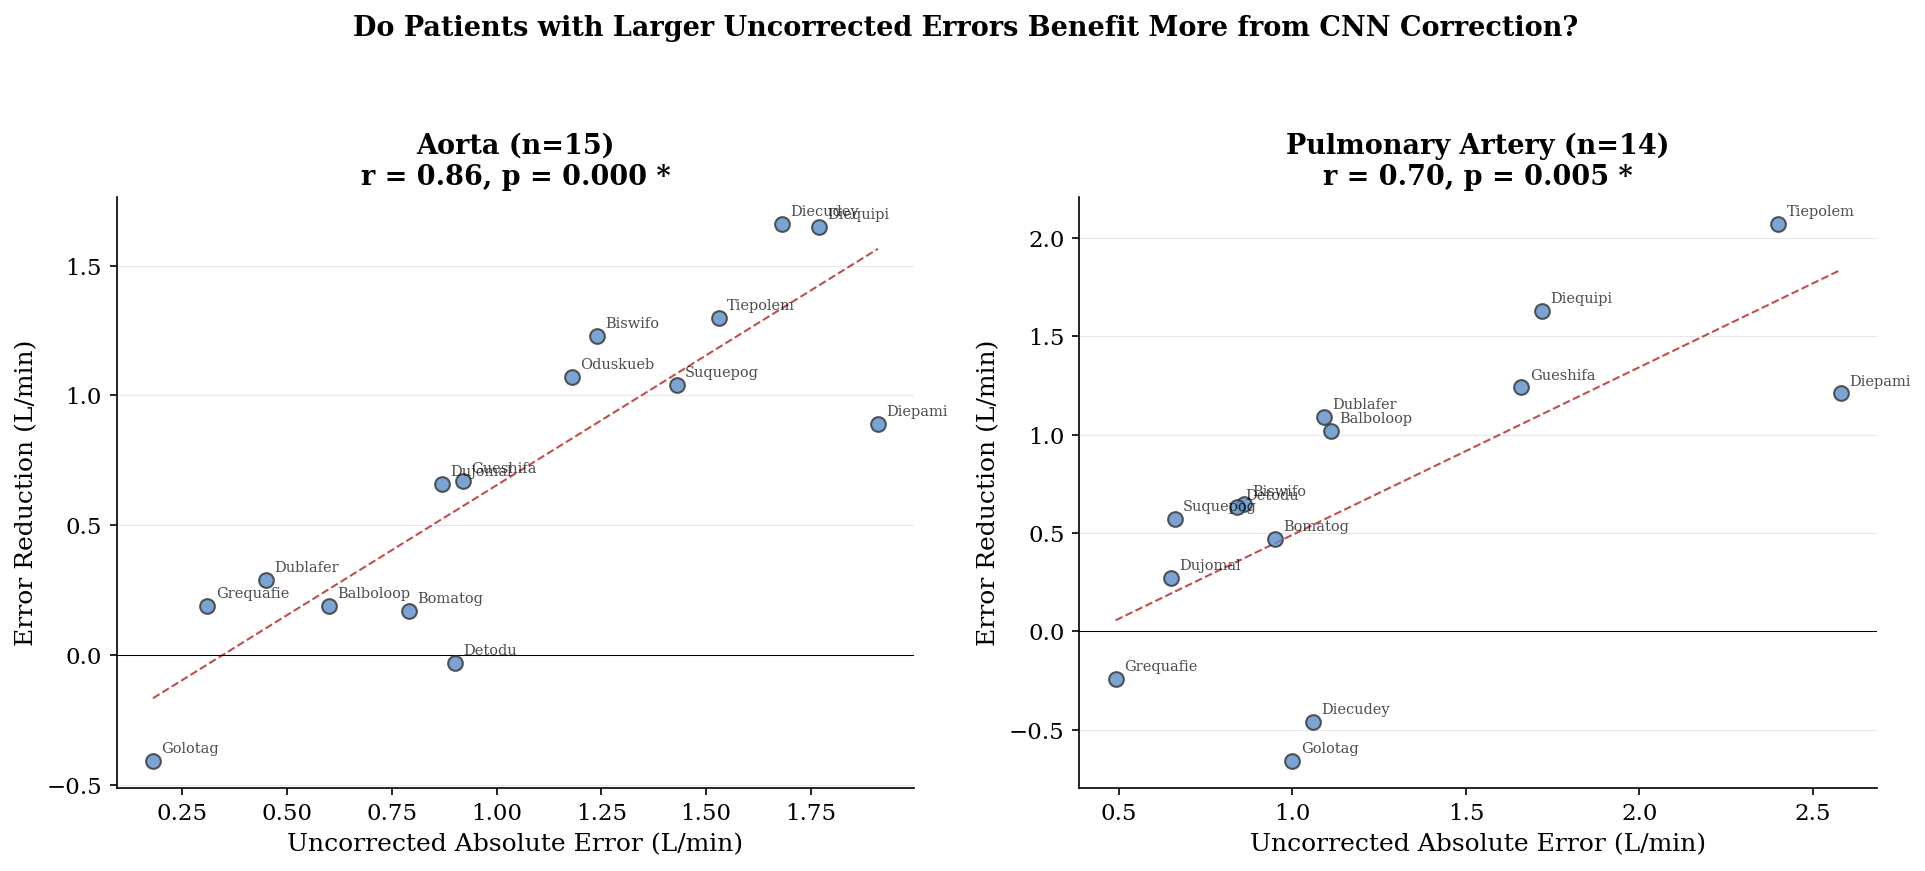

In [6]:
fig, axes = plt.subplots(1, len(VESSELS), figsize=(6.5 * len(VESSELS), 5.5))

for ax, vessel in zip(axes, VESSELS):
    col = f"reduction_{vessel}"
    pred = f"uncorr_abs_error_{vessel}"

    valid = combined[[pred, col]].dropna()
    if len(valid) < 4:
        ax.set_visible(False)
        continue

    r, p = stats.pearsonr(valid[pred], valid[col])

    ax.scatter(valid[pred], valid[col], c="#5B8EC9", edgecolors="#333",
               s=50, alpha=0.8, zorder=3)
    for pt in valid.index:
        ax.annotate(pt, (valid.loc[pt, pred], valid.loc[pt, col]),
                    fontsize=7, alpha=0.7, xytext=(4, 4), textcoords="offset points")

    z = np.polyfit(valid[pred], valid[col], 1)
    xline = np.linspace(valid[pred].min(), valid[pred].max(), 50)
    ax.plot(xline, np.polyval(z, xline), "--", color="#c0504d", linewidth=1)

    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_xlabel("Uncorrected Absolute Error (L/min)")
    ax.set_ylabel("Error Reduction (L/min)")
    sig = " *" if p < 0.05 else ""
    ax.set_title(f"{VESSEL_LABELS[vessel]} (n={len(valid)})\nr = {r:.2f}, p = {p:.3f}{sig}", fontweight="bold")

fig.suptitle("Do Patients with Larger Uncorrected Errors Benefit More from CNN Correction?",
             fontsize=13, fontweight="bold", y=1.05)
fig.tight_layout()
plt.show()

## 6. Ao vs PA correction benefit

Does a patient who benefits in Ao also benefit in PA?

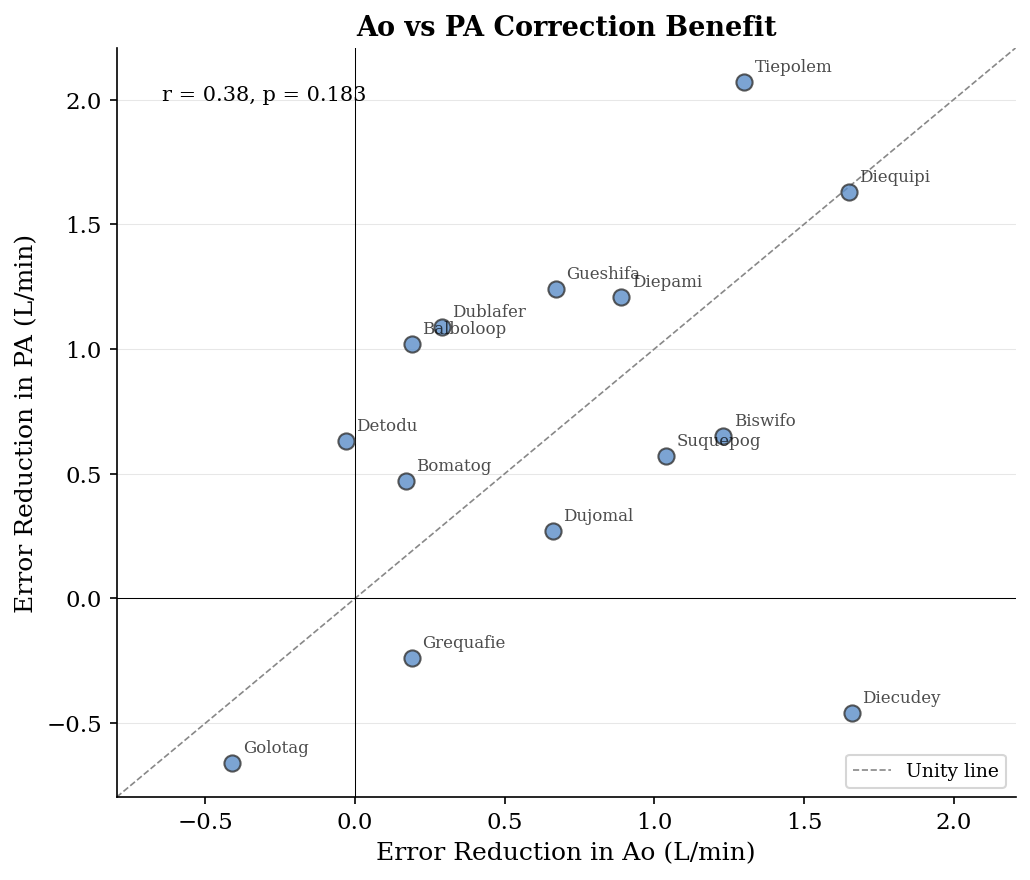

In [7]:
valid = response.dropna()

if len(valid) >= 4:
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(valid["reduction_Ao"], valid["reduction_PA"],
               c="#5B8EC9", edgecolors="#333", s=60, alpha=0.8, zorder=3)
    for pt in valid.index:
        ax.annotate(pt, (valid.loc[pt, "reduction_Ao"], valid.loc[pt, "reduction_PA"]),
                    fontsize=8, alpha=0.7, xytext=(5, 5), textcoords="offset points")

    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
            max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, "--", color="#888", linewidth=0.8, label="Unity line")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.5)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel("Error Reduction in Ao (L/min)")
    ax.set_ylabel("Error Reduction in PA (L/min)")
    ax.set_title("Ao vs PA Correction Benefit", fontweight="bold")

    r, p = stats.pearsonr(valid["reduction_Ao"], valid["reduction_PA"])
    ax.text(0.05, 0.95, f"r = {r:.2f}, p = {p:.3f}", transform=ax.transAxes,
            fontsize=10, va="top")
    ax.legend(fontsize=9)

    fig.tight_layout()
    plt.show()
else:
    print("Not enough patients with both Ao and PA data for this analysis.")

## 7. Summary: patients with notable comments

Check how patients with clinical annotations (shunts, Fontan, VSD)
performed relative to the rest of the cohort.

In [8]:
raw = pd.read_csv(
    NOTEBOOK_DIR / "Cardiac 3D Cine _ 4D Flow - test-population_flow-measurements_albert.csv"
)
comments = raw[["Original PID [UCSD - Radiology]", "Comments"]].rename(
    columns={"Original PID [UCSD - Radiology]": "patient"}
)
comments = comments[comments["Comments"].notna()]

error_by_patient = flow_pivot.pivot_table(
    index="patient", columns="vessel",
    values=["cnn_abs_error", "uncorrected_abs_error"]
)
error_by_patient.columns = [f"{m}_{v}" for m, v in error_by_patient.columns]

annotated = comments.set_index("patient").join(response).join(error_by_patient)

print("Patients with clinical annotations and their correction outcomes:")
display(annotated.round(3))

Patients with clinical annotations and their correction outcomes:


,Comments,reduction_Ao,reduction_PA,cnn_abs_error_Ao,cnn_abs_error_PA,uncorrected_abs_error_Ao,uncorrected_abs_error_PA
patient,,,,,,,
Dublafer,good CNN correction,0.29,1.09,0.16,0.00,0.45,1.09
Golotag,shunt / papvr,-0.41,-0.66,0.59,1.66,0.18,1.00
Gueshifa,good CNN correction,0.67,1.24,0.25,0.42,0.92,1.66
Oduskueb,fontan,1.07,NaN,0.11,NaN,1.18,NaN
Suquepog,"vsd, good CNN correction",1.04,0.57,0.39,0.09,1.43,0.66
Tiepolem,shunt / PDA,1.30,2.07,0.23,0.33,1.53,2.40
